In [2]:
from load_data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

c_blue, c_orange = sns.color_palette("Set2", 2)
palette = {
    "stationary_cam": c_blue,
    "dynamic_cam": c_orange,
}

In [3]:
loader = DataLoader()
loader.load_data()
df = loader.data
df_questionnaire = loader.questionnaire
df_questionnaire_preferences = loader.questionnaire_preferences

**OBJECTIVE**

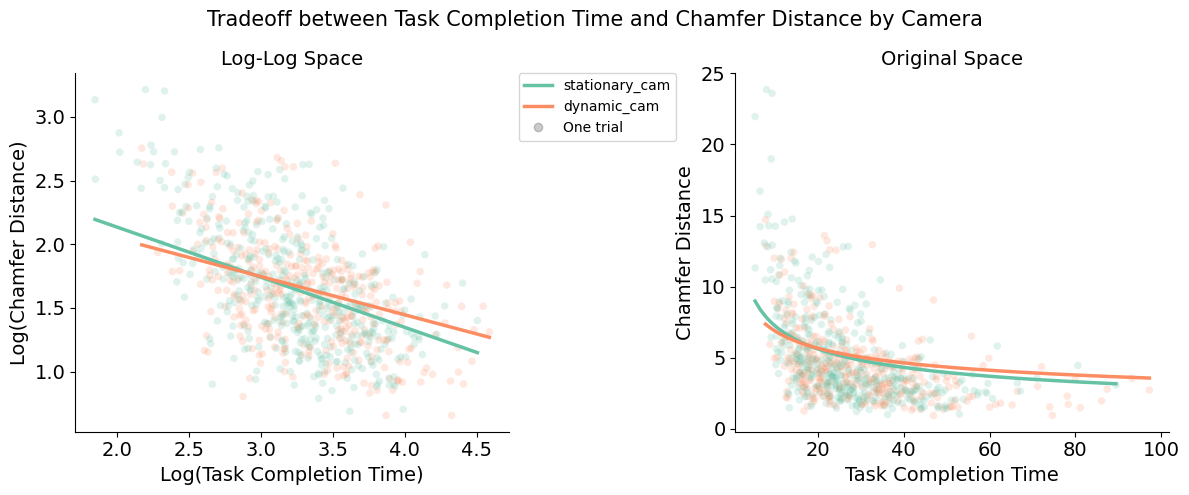

In [23]:
model = smf.mixedlm("log_c ~ log_d * camera", data=df, groups=df["participant"], re_formula="~camera")
result = model.fit()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Log-Log Space
sns.scatterplot(
    data=df, x="log_d", y="log_c",
    hue="camera", palette=palette,
    alpha=0.2, s=30, ax=ax[0], legend=False
)
sns.lineplot(
    data=df, x="log_d", y=result.predict(df),
    hue="camera",
    palette=palette,
    legend=False, ax=ax[0], linewidth=2.5,
)
sns.despine(top=True, right=True, ax=ax[0])
ax[0].set_title("Log-Log Space", fontsize=14)
ax[0].set_xlabel("Log(Task Completion Time)", fontsize=14)
ax[0].set_ylabel("Log(Chamfer Distance)", fontsize=14)

# Original Space
sns.scatterplot(
    data=df, x="duration", y="chamfer_distance",
    hue="camera", palette=palette,
    alpha=0.2, s=30, ax=ax[1], legend=False
)
sns.lineplot(
    data=df, x="duration", y=np.exp(result.predict(df)),
    hue="camera",
    palette=palette,
    ax=ax[1],
    linewidth=2.5,
)
sns.despine(top=True, right=True, ax=ax[1])
ax[1].set_title("Original Space", fontsize=14)
ax[1].set_xlabel("Task Completion Time", fontsize=14)
ax[1].set_ylabel("Chamfer Distance", fontsize=14)

dot_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None', label='One trial', alpha=0.2)
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles=handles + [dot_handle], bbox_to_anchor=(-0.5, 1), loc="upper left", borderaxespad=0.0)

for a in ax:
    a.tick_params(axis='both', labelsize=14)

plt.suptitle("Tradeoff between Task Completion Time and Chamfer Distance by Camera", fontsize=15)
plt.tight_layout()
plt.show()

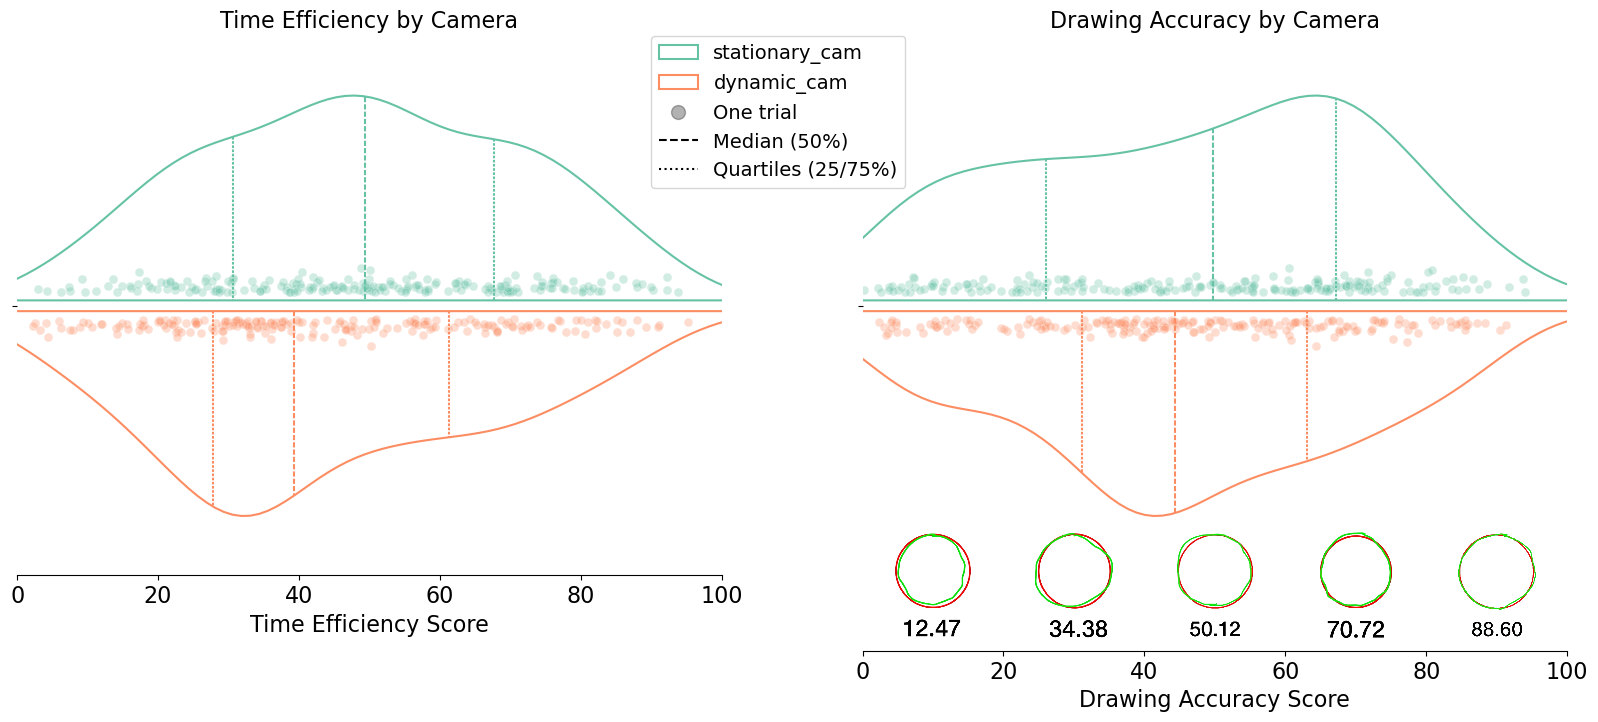

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7), sharey=True)


sigma=0.015
eps1 = abs(np.random.normal(0, sigma, size=df[(df['block'] != 3) & (df['camera'] == 'dynamic_cam')].shape[0])) # df['efficiency']
eps2 = abs(np.random.normal(0, sigma, size=df[(df['block'] != 3) & (df['camera'] == 'stationary_cam')].shape[0])) # df['efficiency']

sns.scatterplot(x='efficiency', y=0.025+eps1, data=df[(df['block'] != 3) & (df['camera'] == 'dynamic_cam')], ax=ax[0], color=c_orange, alpha=0.3, s=40, legend=False)
sns.scatterplot(x='efficiency', y=-0.025-eps2, data=df[(df['block'] != 3) & (df['camera'] == 'stationary_cam')], ax=ax[0], color=c_blue, alpha=0.3, s=40, legend=False)
sns.violinplot(x='efficiency', hue='camera', data=df[df['block'] != 3], ax=ax[0], fill=False, split=True, legend=False, palette=palette, inner='quart', gap=.05, linewidth=1.5)
ax[0].set_title('Time Efficiency by Camera', fontsize=16)
ax[0].set_xlabel('Time Efficiency Score', fontsize=16)
ax[0].set_xlim(0, 100)
sns.despine(top=True, right=True, left=True, ax=ax[0])

sns.scatterplot(x='accuracy', y=0.025+eps1, data=df[(df['block'] != 3) & (df['camera'] == 'dynamic_cam')], ax=ax[1], color=c_orange, alpha=0.3, s=40, legend=False)
sns.scatterplot(x='accuracy', y=-0.025-eps2, data=df[(df['block'] != 3) & (df['camera'] == 'stationary_cam')], ax=ax[1], color=c_blue, alpha=0.3, s=40, legend=False)
sns.violinplot(x='accuracy', hue='camera', data=df[df['block'] != 3], split=True, ax=ax[1], fill=False, palette=palette, inner='quart', gap=.05, linewidth=1.5)
ax[1].set_title('Drawing Accuracy by Camera', fontsize=16)
ax[1].set_xlabel('Drawing Accuracy Score', fontsize=16)
ax[1].set_xlim(0, 100)
sns.despine(top=True, right=True, left=True, ax=ax[1])
ax[1].spines['bottom'].set_position(('axes', -0.14))

# Get x-tick positions
xticks = ax[1].get_xticks()
image_paths = ['img1.png', 'img2.png', 'img3.png', 'img4.png', 'img5.png']

for i in range(len(xticks) - 1):
    midpoint = (xticks[i] + xticks[i+1]) / 2
    img = mpimg.imread(image_paths[i])
    imagebox = OffsetImage(img, zoom=0.23)
    ab = AnnotationBbox(imagebox, (midpoint, ax[1].get_ylim()[0] - 0.10), 
                        frameon=False, xycoords=('data', 'data'), box_alignment=(0.5, 1))
    ax[1].add_artist(ab)

handles, labels = ax[1].get_legend_handles_labels()
scatter_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None', alpha=0.3, markersize=10, label='One trial')
median_handle = mlines.Line2D([], [], color='black', linestyle='--', linewidth=1.5, label='Median (50%)')
quartile_handle = mlines.Line2D([], [], color='black', linestyle=':', linewidth=1.5, label='Quartiles (25/75%)')

for a in ax:
    a.tick_params(axis='both', labelsize=16)

plt.legend(
    handles=handles + [scatter_handle, median_handle, quartile_handle],
    bbox_to_anchor=(-0.3, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=14
)
plt.show()

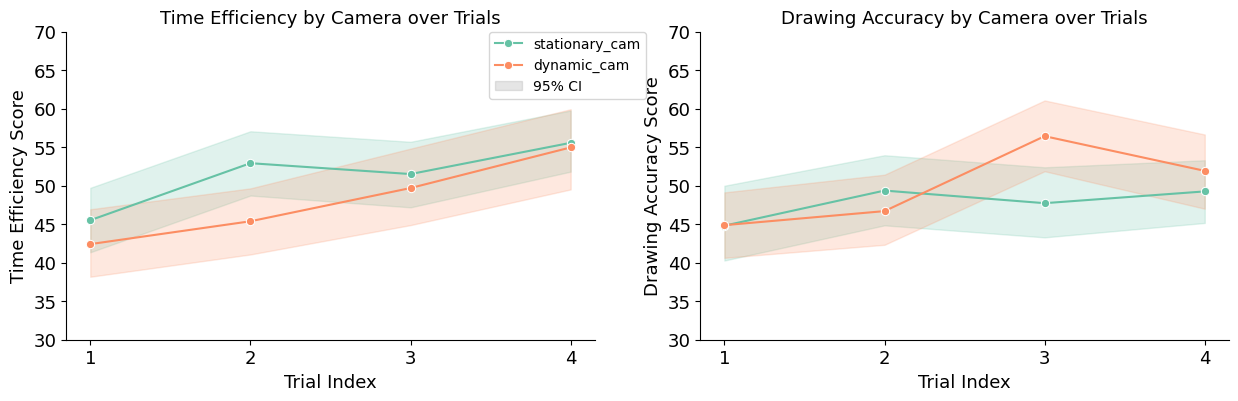

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4), sharex=True)

sns.lineplot(data=df, x="shape_trial_idx", y="efficiency", hue="camera", ax=ax[0], marker="o", legend=False, palette=palette)
ax[0].set_title("Time Efficiency by Camera over Trials", fontsize=13)
ax[0].set_xticks([1, 2, 3, 4])
ax[0].set_xlabel('Trial Index', fontsize=13)
ax[0].set_ylabel('Time Efficiency Score', fontsize=13)
ax[0].set_ylim(30, 70)
sns.despine(top=True, right=True, ax=ax[0])

sns.lineplot(data=df, x="shape_trial_idx", y="accuracy", hue="camera", ax=ax[1], marker="o", palette=palette)
ax[1].set_title("Drawing Accuracy by Camera over Trials", fontsize=13)
ax[1].set_xticks([1, 2, 3, 4])
ax[1].set_xlabel('Trial Index', fontsize=13)
ax[1].set_ylabel('Drawing Accuracy Score', fontsize=13)
ax[1].set_ylim(30, 70)
sns.despine(top=True, right=True, ax=ax[1])

ci_patch = mpatches.Patch(color='gray', alpha=0.2, label='95% CI')
handles, labels = ax[1].get_legend_handles_labels()
plt.legend(
    handles=handles + [ci_patch],
    bbox_to_anchor=(-0.4, 1),
    loc='upper left',
    borderaxespad=0.,
)

for a in ax:
    a.tick_params(axis='both', labelsize=13)

plt.show()

**SUBJECTIVE**

*Questionnaire*

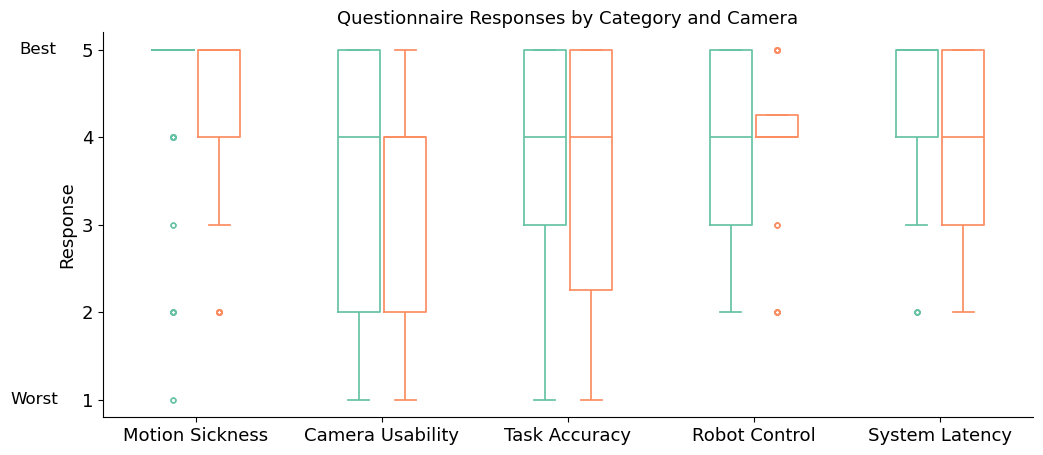

In [37]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_questionnaire, x='category', y='Response', hue='camera', fill=False, width=0.5, palette=palette, gap=.1, linewidth=1.25, fliersize=3.5, legend=False)
plt.title("Questionnaire Responses by Category and Camera", fontsize=13)
plt.ylabel("Response", fontsize=13)
plt.xlabel("")
sns.despine(top=True, right=True)
plt.yticks([1, 2, 3, 4, 5])
plt.tick_params(axis='both', labelsize=13)

plt.text(-0.95, 4.95, 'Best', fontsize=12)
plt.text(-1, 0.95, 'Worst', fontsize=12)

plt.show()

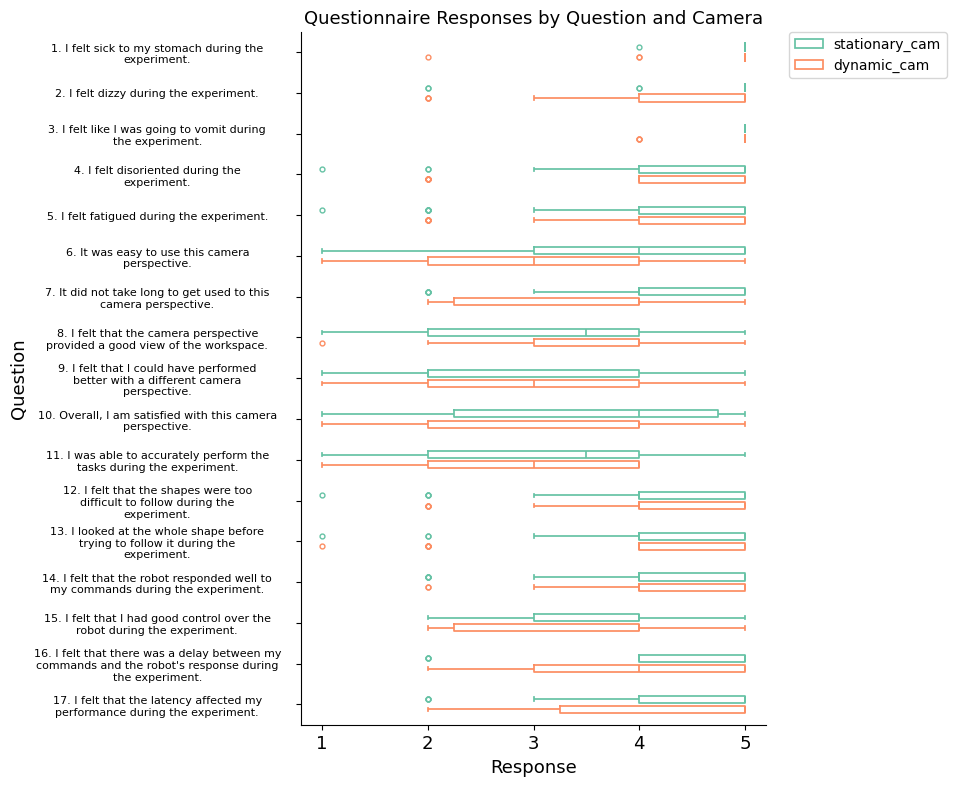

In [39]:
import textwrap
df_questionnaire['Q'] = df_questionnaire['Question'].apply(lambda x: '\n'.join(textwrap.wrap(x, 40)))

for i, q in enumerate(df_questionnaire['Q'].unique()):
    df_questionnaire.loc[df_questionnaire['Q'] == q, 'Q'] = f"{i+1}. {q}"

plt.figure(figsize=(6, 9))
sns.boxplot(y='Q', x='Response', hue='camera', data=df_questionnaire, orient='h', palette=palette, fill=False, width=0.5, gap=.3, linewidth=1.25, fliersize=3.5)
plt.title('Questionnaire Responses by Question and Camera', fontsize=13)
plt.xlabel('Response', fontsize=13)
plt.ylabel('Question', fontsize=13)
plt.yticks(fontsize=8, ha='center')
plt.gca().yaxis.set_tick_params(pad=100)
sns.despine(top=True, right=True)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
)
plt.xticks([1, 2, 3, 4, 5], fontsize=13)
plt.show()

*Preferences*

In [8]:
# convert categories
df_questionnaire_preferences['preferred_camera_num'] = df_questionnaire_preferences['preferred_camera'].map({
    'stationary_cam': 1,
    'dynamic_cam': -1,
})

# pivot
pivot = df_questionnaire_preferences.pivot(
    index='participant',
    columns='shape',
    values='preferred_camera_num'
)

shape_order = [
    'In General',
    'star',
    'flower',
    'circle',
    'heart',
    'triangle',
    'square',
    'writing'
]

pivot = pivot[shape_order]

pivot['sum'] = pivot.sum(axis=1)
pivot = pivot.sort_values(by='sum', ascending=False).drop(columns=['sum'])

In [9]:
df_preferred_camera = df_questionnaire_preferences.groupby(["preferred_camera", "shape"]).size().reset_index(name="count")
df_preferred_camera["percentage"] = df_preferred_camera.groupby("shape")["count"].transform(lambda x: x / x.sum() * 100)
df_preferred_camera.drop(columns=['count'], inplace=True)
df_preferred_camera = df_preferred_camera.set_index('shape').loc[shape_order].reset_index()
df_preferred_camera = df_preferred_camera.sort_values(by='preferred_camera', ascending=False)

In [10]:
camera_counts = df_questionnaire_preferences.groupby(['participant', 'preferred_camera']).size().unstack(fill_value=0)
camera_counts['abs_diff'] = (camera_counts.get('stationary_cam', 0) - camera_counts.get('dynamic_cam', 0)).abs()
camera_counts['preferred_camera'] = camera_counts.apply(lambda row: 'stationary_cam' if row['stationary_cam'] > row['dynamic_cam'] else 'dynamic_cam', axis=1)

participants_order = pivot.index.tolist()
camera_counts = camera_counts.reindex(participants_order)

In [11]:
df_questionnaire_preferences['pref_num'] = df_questionnaire_preferences['preferred_camera'].map({
    'stationary_cam': 1,
    'dynamic_cam': -1
})

scores = pd.DataFrame(df_questionnaire_preferences.groupby('participant')['pref_num'].mean().sort_values())

participants_order = pivot.index.tolist()
scores = scores.reindex(participants_order)
scores['abs'] = scores['pref_num'].abs()
scores['pref_cam'] = scores['pref_num'].apply(lambda x: 'stationary_cam' if x > 0 else 'dynamic_cam')

scores_double = scores.copy()
row_idx = scores_double.size
for row in scores_double.itertuples():
    if row.pref_num == 0:
        scores_double.loc[row_idx] = {
            'pref_num': 0,
            'abs': 0,
            'pref_cam': 'stationary_cam',
        }
        row_idx += 1

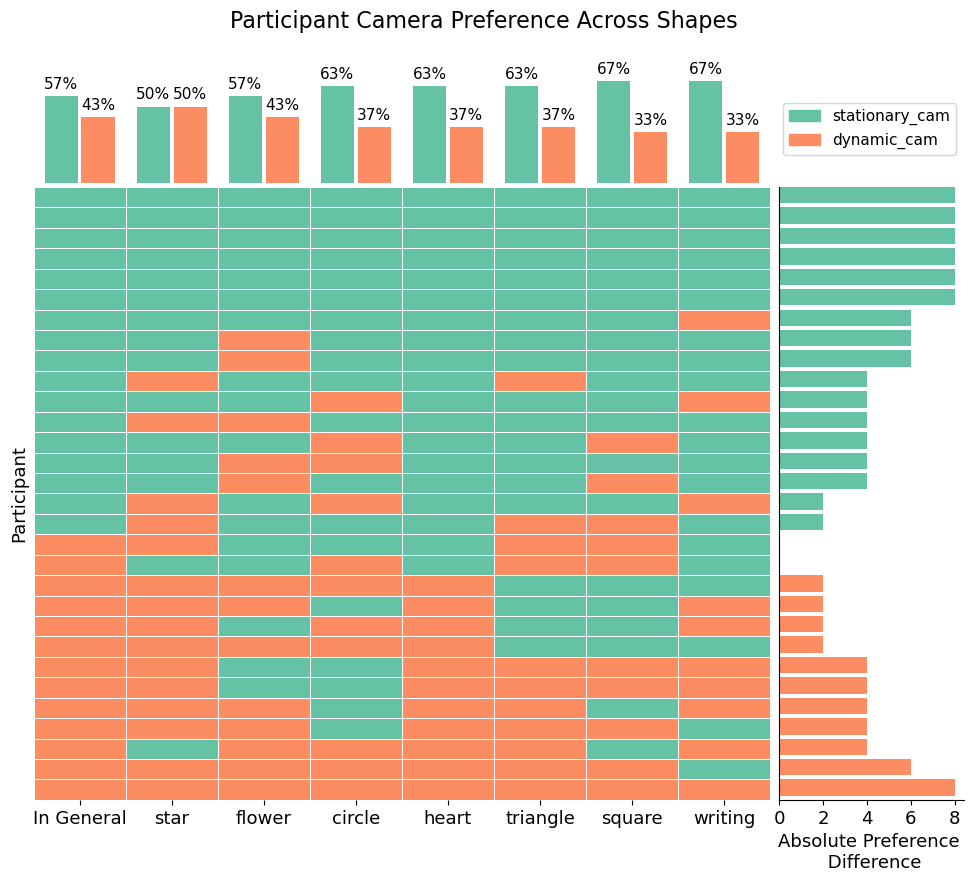

In [41]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 0.5], wspace=0.02, height_ratios=[0.5, 2], hspace=0.01)

ax0 = fig.add_subplot(gs[0, 0])  # bar plot
ax2 = fig.add_subplot(gs[1, 0])  # heatmap
ax3 = fig.add_subplot(gs[1, 1], sharey=ax2)  # bar plot shares y

# --- bar plot ---
sns.barplot(
    x=df_preferred_camera['shape'], 
    y=df_preferred_camera['percentage'], 
    hue=df_preferred_camera['preferred_camera'], 
    palette=palette,
    ax=ax0, 
    legend=False, 
    gap=.1,
    saturation=1,
)
ax0.set_ylim(0, 100)
ax0.set_yticks([])
ax0.set_xticks([])
ax0.set_xlabel("")
ax0.set_ylabel("")
for p in ax0.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax0.annotate(
            f"{height:.0f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=11,
            xytext=(0, 3),
            textcoords='offset points'
        )
sns.despine(top=True, right=True, left=True, bottom=True, ax=ax0)

# --- heatmap ---
cmap = ListedColormap([
  palette["dynamic_cam"],
  palette["stationary_cam"]
])
sns.heatmap(
    pivot,
    cmap=cmap,
    linewidths=0.5,
    cbar=False,
    ax=ax2,
)
ax2.set_xlabel("")
ax2.set_ylabel("Participant", fontsize=13)

# --- bar plot ---
ax3.barh(
    camera_counts.index, 
    camera_counts['abs_diff'], 
    align='edge', 
    color=camera_counts['preferred_camera'].map(palette)
)
ax3.set_xlabel("Absolute Preference \n Difference", fontsize=13)
ax3.set_xticks([0, 2, 4, 6, 8])
ax3.set_ylabel("")
ax3.set_yticks([])
sns.despine(ax=ax3, top=True, right=True)

bound = ax3.get_xbound()

# --- legend ---
legend_handles = [
    mpatches.Patch(color=palette["stationary_cam"], label="stationary_cam"),
    mpatches.Patch(color=palette["dynamic_cam"], label="dynamic_cam"),
]

plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(1, 1.15),
    loc="upper right", fontsize=11
)
fig.suptitle(
    "Participant Camera Preference Across Shapes",
    y=0.9, fontsize=16
)

for a in [ax0, ax2, ax3]:
    a.tick_params(axis='both', labelsize=13)

plt.show()

**COMPARE SUBJECTIVE VS OBJECTIVE**

In [13]:
colors = [c_blue, c_orange]

def stacked_pref_plot(ax, summary, title, show_title=True, show_xlabel=True, show_ylabel=True):
    used_true = summary
    used_false = 100 - summary

    ax.bar(summary.index, used_true, color=colors, label="Matched preference")
    ax.bar(summary.index, used_false, bottom=used_true, color=colors, alpha=0.3, label="Did not match")

    for i, (idx, val) in enumerate(used_true.items()):
        ax.text(i, val / 2, f"{val:.1f}%", ha="center", va="center", fontsize=14, color="white", fontweight="bold")
    for i, (idx, val) in enumerate(used_false.items()):
        ax.text(i, used_true.iloc[i] + val / 2, f"{val:.1f}%", ha="center", va="center", fontsize=14, color="gray")

    ax.set_yticks([])
    if show_ylabel:
        ax.set_ylabel("Percentage (%)", fontsize=14)
    if show_xlabel:
        ax.set_xlabel("Preferred Camera", fontsize=14)
    if show_title:
        ax.set_title(title, fontsize=14)

In [14]:
def compute_preference_summaries(df, df_questionnaire_preferences, metric):
    # General preference vs best block
    df_preference_general = (
        df_questionnaire_preferences
        .loc[df_questionnaire_preferences['shape'] == 'In General', ['participant', 'preferred_camera']]
        .rename(columns={'preferred_camera': 'preferred_camera_general'})
    )
    # For each participant, find the camera with the highest mean metric (excluding block 3)
    df_best_general = df[df['block'] != 3].groupby(['participant', 'camera'])[metric].mean().reset_index()
    idx = df_best_general.groupby('participant')[metric].idxmax()
    df_best_general = df_best_general.loc[idx].reset_index(drop=True)
    df_best_general = df_best_general.merge(df_preference_general, on=['participant'], how='left')
    df_best_general['used_preferred_camera'] = df_best_general['camera'] == df_best_general['preferred_camera_general']
    summary_general = (
        df_best_general
        .groupby("preferred_camera_general")["used_preferred_camera"]
        .mean()
        .mul(100)
        .reindex(["stationary_cam", "dynamic_cam"])
        .fillna(0)
    )

    # Per-shape preference vs best trial
    df_best_shape = df[df['block'] != 3].copy()
    idx = df_best_shape.groupby(['participant', 'shape'])[metric].idxmax()
    df_best_shape = df_best_shape.loc[idx].reset_index(drop=True)
    df_best_shape = df_best_shape.merge(df_questionnaire_preferences, on=['participant', 'shape'], how='left')
    df_best_shape['used_preferred'] = df_best_shape['camera'] == df_best_shape['preferred_camera']
    participant_match = (
        df_best_shape.groupby(['participant', 'preferred_camera'])['used_preferred']
        .mean()
        .reset_index()
    )
    participant_match['used_preferred_camera'] = participant_match['used_preferred'] > 0.5
    summary_shape = (
        participant_match
        .groupby("preferred_camera")["used_preferred_camera"]
        .mean()
        .mul(100)
        .reindex(["stationary_cam", "dynamic_cam"])
        .fillna(0)
    )
    return summary_general, summary_shape

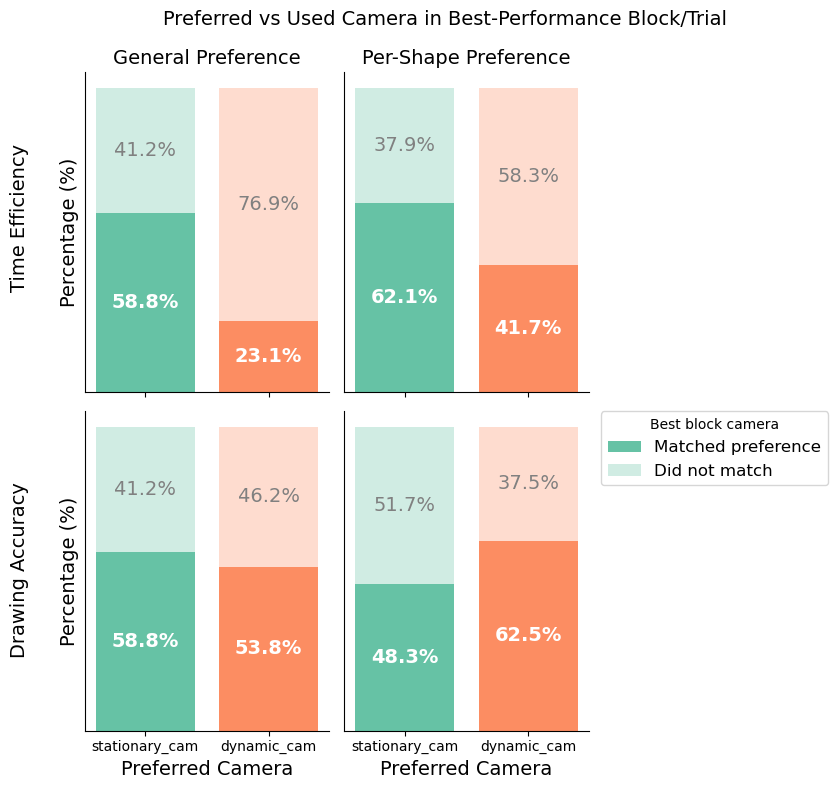

In [44]:
# Compute summaries
summary_general_eff, summary_shape_eff = compute_preference_summaries(df, df_questionnaire_preferences, "efficiency")
summary_general_acc, summary_shape_acc = compute_preference_summaries(df, df_questionnaire_preferences, "accuracy")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
stacked_pref_plot(axes[0, 0], summary_general_eff, "General Preference", show_title=True, show_xlabel=False, show_ylabel=True)
stacked_pref_plot(axes[0, 1], summary_shape_eff, "Per-Shape Preference", show_title=True, show_xlabel=False, show_ylabel=False)
stacked_pref_plot(axes[1, 0], summary_general_acc, "", show_title=False, show_xlabel=True, show_ylabel=True)
stacked_pref_plot(axes[1, 1], summary_shape_acc, "", show_title=False, show_xlabel=True, show_ylabel=False)

fig.text(-0.02, 0.72, "Time Efficiency", va='center', ha='right', rotation=90, fontsize=14)
fig.text(-0.02, 0.28, "Drawing Accuracy", va='center', ha='right', rotation=90, fontsize=14)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    title="Best block camera",
    labels=["Matched preference", "Did not match"],
    fontsize=12
)
for ax_row in axes:
    for ax in ax_row:
        sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle("Preferred vs Used Camera in Best-Performance Block/Trial", fontsize=14)
plt.show()